In [24]:
# 1. Importing required libraries for getting webpage data, extracting data from HTML, and analyzing data
import requests
from bs4 import BeautifulSoup
import pandas as pd
import re
from urllib.parse import urljoin
import matplotlib.pyplot as plt

In [25]:
# Main website URL from which I'm collecting the book data
website_url = "http://books.toscrape.com/"

In [26]:
# 2. Using HTTP Headers wherever required
headers = {
    "User-Agent": "Mozilla/5.0"
}

In [27]:
# 2.1 Data Collection using Requests and Headers
# Sending a request to the website and storing the response
response = requests.get(website_url, headers=headers)
print("Status Code:", response.status_code)


Status Code: 200


In [28]:
# 3. Using BeautifulSoup to extract data from HTML
response.encoding = "utf-8"
soup = BeautifulSoup(response.text, "html.parser")
print(soup.title.text)


    All products | Books to Scrape - Sandbox



In [29]:
# Finding all the books available on the page
books = soup.find_all("article", class_="product_pod")

print("Number of books:", len(books))

Number of books: 20


In [30]:
### 4. Extracting Book Details

In [31]:
# Selecting the first book
book = books[0]

# Getting the book name
book_name = book.h3.a["title"]

# Getting the price of the book
price = book.find("p", class_="price_color").text

# Getting the rating
rating = book.find("p", class_="star-rating")["class"][1]

# Getting the availability
availability = book.find("p", class_="instock availability").text.strip()

print("Book:", book_name)
print("Price:", price)
print("Rating:", rating)
print("Availability:", availability)

# Getting the link of the book
book_link = book.h3.a["href"]

print(book_link)

Book: A Light in the Attic
Price: £51.77
Rating: Three
Availability: In stock
catalogue/a-light-in-the-attic_1000/index.html


In [32]:
# Finding all the links on the page
category_section = soup.find("ul", class_="nav-list")
print(category_section)

<ul class="nav nav-list">
<li>
<a href="catalogue/category/books_1/index.html">
                            
                                Books
                            
                        </a>
<ul>
<li>
<a href="catalogue/category/books/travel_2/index.html">
                            
                                Travel
                            
                        </a>
</li>
<li>
<a href="catalogue/category/books/mystery_3/index.html">
                            
                                Mystery
                            
                        </a>
</li>
<li>
<a href="catalogue/category/books/historical-fiction_4/index.html">
                            
                                Historical Fiction
                            
                        </a>
</li>
<li>
<a href="catalogue/category/books/sequential-art_5/index.html">
                            
                                Sequential Art
                            
           

In [33]:
# 4.1 Get Categories and Category URLs
# Finding all category links
category_links = category_section.find_all("a")

# Getting category names and their links
for link in category_links:
    category_name = link.text.strip()
    category_url = link.get("href")
    
    print(category_name, "->", category_url)

Books -> catalogue/category/books_1/index.html
Travel -> catalogue/category/books/travel_2/index.html
Mystery -> catalogue/category/books/mystery_3/index.html
Historical Fiction -> catalogue/category/books/historical-fiction_4/index.html
Sequential Art -> catalogue/category/books/sequential-art_5/index.html
Classics -> catalogue/category/books/classics_6/index.html
Philosophy -> catalogue/category/books/philosophy_7/index.html
Romance -> catalogue/category/books/romance_8/index.html
Womens Fiction -> catalogue/category/books/womens-fiction_9/index.html
Fiction -> catalogue/category/books/fiction_10/index.html
Childrens -> catalogue/category/books/childrens_11/index.html
Religion -> catalogue/category/books/religion_12/index.html
Nonfiction -> catalogue/category/books/nonfiction_13/index.html
Music -> catalogue/category/books/music_14/index.html
Default -> catalogue/category/books/default_15/index.html
Science Fiction -> catalogue/category/books/science-fiction_16/index.html
Sports and 

In [34]:
# Removing the main Books link
category_links = [
    link for link in category_links
    if link.text.strip() != "Books"
]
# Creating lists to store category names and URLs
category_names = []
category_urls = []

# Storing the category names and URLs
for link in category_links:
    category_names.append(link.text.strip())
    category_urls.append(link.get("href"))

# Checking the first 5 categories and URLs
for i in range(5):
    print(category_names[i], "->", category_urls[i])

Travel -> catalogue/category/books/travel_2/index.html
Mystery -> catalogue/category/books/mystery_3/index.html
Historical Fiction -> catalogue/category/books/historical-fiction_4/index.html
Sequential Art -> catalogue/category/books/sequential-art_5/index.html
Classics -> catalogue/category/books/classics_6/index.html


In [35]:
# Creating the complete URLs for all categories
full_category_urls = []

for url in category_urls:
    full_url = website_url + url
    full_category_urls.append(full_url)

# Checking the first 5 category URLs
for i in range(5):
    print(category_names[i], "->", full_category_urls[i])


Travel -> http://books.toscrape.com/catalogue/category/books/travel_2/index.html
Mystery -> http://books.toscrape.com/catalogue/category/books/mystery_3/index.html
Historical Fiction -> http://books.toscrape.com/catalogue/category/books/historical-fiction_4/index.html
Sequential Art -> http://books.toscrape.com/catalogue/category/books/sequential-art_5/index.html
Classics -> http://books.toscrape.com/catalogue/category/books/classics_6/index.html


In [36]:
### 4.2 Genration and validation of complete urls for categories
# Testing the first category page
category_response = requests.get(full_category_urls[0], headers=headers)

# Setting the correct encoding for the webpage
category_response.encoding = "utf-8"

print("Status Code:", category_response.status_code)
print(category_response.url)

Status Code: 200
http://books.toscrape.com/catalogue/category/books/travel_2/index.html


In [37]:
### 4.3 Scraping Book Details from Category Pages

In [38]:
# Reading the first category page using BeautifulSoup
category_soup = BeautifulSoup(category_response.text, "html.parser")

# Finding all books on the category page
category_books = category_soup.find_all("article", class_="product_pod")

print("Number of books:", len(category_books))

Number of books: 11


In [39]:
# Extracting details of the books on the page
for book in category_books:
    book_name = book.h3.a["title"]
    price = book.find("p", class_="price_color").text
    rating = book.find("p", class_="star-rating")["class"][1]
    availability = book.find("p", class_="instock availability").text.strip()

    print(book_name)
    print(price)
    print(rating)
    print(availability)
    print()

It's Only the Himalayas
£45.17
Two
In stock

Full Moon over Noah’s Ark: An Odyssey to Mount Ararat and Beyond
£49.43
Four
In stock

See America: A Celebration of Our National Parks & Treasured Sites
£48.87
Three
In stock

Vagabonding: An Uncommon Guide to the Art of Long-Term World Travel
£36.94
Two
In stock

Under the Tuscan Sun
£37.33
Three
In stock

A Summer In Europe
£44.34
Two
In stock

The Great Railway Bazaar
£30.54
One
In stock

A Year in Provence (Provence #1)
£56.88
Four
In stock

The Road to Little Dribbling: Adventures of an American in Britain (Notes From a Small Island #2)
£23.21
One
In stock

Neither Here nor There: Travels in Europe
£38.95
Three
In stock

1,000 Places to See Before You Die
£26.08
Five
In stock



In [40]:
# Checking if another page is available for this category
next_page = category_soup.find("li", class_="next")

if next_page:
    print("Next page is available")
else:
    print("No next page")

No next page


In [41]:
# Getting the Default category URL
default_url = full_category_urls[category_names.index("Default")]
print(default_url)
# Sending a request to the category page
category_response = requests.get(default_url, headers=headers)

# Setting the correct encoding for the webpage
category_response.encoding = "utf-8"

print("Status Code:", category_response.status_code)

http://books.toscrape.com/catalogue/category/books/default_15/index.html
Status Code: 200


In [42]:
# Reading the category page
category_soup = BeautifulSoup(category_response.text, "html.parser")

In [43]:
# Checking if another page is available
next_page = category_soup.find("li", class_="next")

if next_page:
    print("Next page is available")
    print(next_page.find("a")["href"])
else:
    print("No next page")

Next page is available
page-2.html


In [44]:
### Validating Dynamic urls and Multiple pages link with one category

In [45]:
# Creating the next page URL
if next_page:
    next_link = next_page.find("a")["href"]
    next_url = urljoin(category_response.url, next_link)

    print(next_url)

http://books.toscrape.com/catalogue/category/books/default_15/page-2.html


In [46]:
### 4.4 Scraping Multiple Pages using Dynamic URLs

In [47]:
# Creating lists to store the scraped data
book_names = []
categories = []
prices = []
ratings = []
availabilities = []

In [139]:
# Scraping all categories and their pages
for i in range(len(full_category_urls)):
    
    category_name = category_names[i]
    current_url = full_category_urls[i]
    
    while current_url:
        
        # Sending a request to the current page
        response = requests.get(current_url, headers=headers)
        response.encoding = "utf-8"
        
        # Reading the page using BeautifulSoup
        page_soup = BeautifulSoup(response.text, "html.parser")
        
        # Finding all books on the page
        books = page_soup.find_all("article", class_="product_pod")
        
        # Getting details of each book
        for book in books:
            book_name = book.h3.a["title"]
            price = book.find("p", class_="price_color").text
            rating = book.find("p", class_="star-rating")["class"][1]
            availability = book.find(
                "p", class_="instock availability"
            ).text.strip()
            
            book_names.append(book_name)
            categories.append(category_name)
            prices.append(price)
            ratings.append(rating)
            availabilities.append(availability)
        
        # Checking if another page is available
        next_page = page_soup.find("li", class_="next")
        
        if next_page:
            next_link = next_page.find("a")["href"]
            current_url = urljoin(current_url, next_link)
        else:
            current_url = None

In [49]:
# Creating the raw dataset
raw_df = pd.DataFrame({
    "Book": book_names,
    "Category": categories,
    "Price": prices,
    "Rating": ratings,
    "Availability": availabilities
})

print(raw_df.shape)
# Checking the first few records
raw_df.head()

(1000, 5)


,Book,Category,Price,Rating,Availability
0,It's Only the Himalayas,Travel,£45.17,Two,In stock
1,Full Moon over Noah’s Ark: An Odyssey to Mount...,Travel,£49.43,Four,In stock
2,See America: A Celebration of Our National Par...,Travel,£48.87,Three,In stock
3,Vagabonding: An Uncommon Guide to the Art of L...,Travel,£36.94,Two,In stock
4,Under the Tuscan Sun,Travel,£37.33,Three,In stock


In [50]:
### Data scraping and checking the scraped data

In [51]:
# Checking the number of records
print("Total books:", len(raw_df))

# Checking the number of categories
print("Total categories:", raw_df["Category"].nunique())

# Checking for missing values
raw_df.isnull().sum()

Total books: 1000
Total categories: 50


Book            0
Category        0
Price           0
Rating          0
Availability    0
dtype: int64

In [52]:
# Checking for duplicate records
print("Duplicate records:", raw_df.duplicated().sum())

Duplicate records: 0


In [53]:
# Saving the scraped data before cleaning
raw_df.to_csv("raw_books_data.csv", index=False)
raw_df.head()

,Book,Category,Price,Rating,Availability
0,It's Only the Himalayas,Travel,£45.17,Two,In stock
1,Full Moon over Noah’s Ark: An Odyssey to Mount...,Travel,£49.43,Four,In stock
2,See America: A Celebration of Our National Par...,Travel,£48.87,Three,In stock
3,Vagabonding: An Uncommon Guide to the Art of L...,Travel,£36.94,Two,In stock
4,Under the Tuscan Sun,Travel,£37.33,Three,In stock


In [54]:
### 5. Data Cleaning ###

In [55]:
### 5.1 Saving the Raw Dataset

In [56]:
### 5.2 Creating a Copy for Data Cleaning

In [57]:
# Creating a copy of the raw data for cleaning
clean_df = raw_df.copy()

clean_df.head()

,Book,Category,Price,Rating,Availability
0,It's Only the Himalayas,Travel,£45.17,Two,In stock
1,Full Moon over Noah’s Ark: An Odyssey to Mount...,Travel,£49.43,Four,In stock
2,See America: A Celebration of Our National Par...,Travel,£48.87,Three,In stock
3,Vagabonding: An Uncommon Guide to the Art of L...,Travel,£36.94,Two,In stock
4,Under the Tuscan Sun,Travel,£37.33,Three,In stock


In [58]:
### 5.3 Checking Data Types

In [63]:
# Checking the data types of each column
clean_df.dtypes

Book            object
Category        object
Price           object
Rating          object
Availability    object
dtype: object

In [64]:
### 5.4 Data Cleaning using Regular Expressions

In [65]:
# First regex expression - Removing the currency symbol from the price

In [66]:
clean_df["Price"] = clean_df["Price"].str.replace(r"[^\d.]", "", regex=True)
clean_df["Price"].head()

0    45.17
1    49.43
2    48.87
3    36.94
4    37.33
Name: Price, dtype: object

In [67]:
# Second regex expression - Extracting the rating value

In [68]:
# Extracting the rating word from the rating column
clean_df["Rating"] = clean_df["Rating"].str.extract(r"(One|Two|Three|Four|Five)")
clean_df["Rating"].head()

0      Two
1     Four
2    Three
3      Two
4    Three
Name: Rating, dtype: object

In [69]:
# Third regex expression - Extracting the availability status

In [70]:
# Extracting the availability value
clean_df["Availability"] = clean_df["Availability"].str.extract(r"(In stock|Out of stock)")
clean_df["Availability"].head()

0    In stock
1    In stock
2    In stock
3    In stock
4    In stock
Name: Availability, dtype: object

In [71]:
# Fourth regex expression - Extracting the numeric part of the price

In [72]:
# Extracting the numeric value from the price
clean_df["Price"] = clean_df["Price"].str.extract(r"(\d+\.\d+)")
clean_df["Price"].head()

0    45.17
1    49.43
2    48.87
3    36.94
4    37.33
Name: Price, dtype: object

In [73]:
# Fifth regex expression - Cleaning extra spaces from book names

In [74]:
clean_df["Book"] = clean_df["Book"].str.replace(r"\s+", " ", regex=True).str.strip()
clean_df["Book"].head()

0                              It's Only the Himalayas
1    Full Moon over Noah’s Ark: An Odyssey to Mount...
2    See America: A Celebration of Our National Par...
3    Vagabonding: An Uncommon Guide to the Art of L...
4                                 Under the Tuscan Sun
Name: Book, dtype: object

In [75]:
# Sixth regex expression - Cleaning extra spaces from category names

In [76]:
clean_df["Category"] = clean_df["Category"].str.replace(r"\s+", " ", regex=True).str.strip()
clean_df["Category"].head()

0    Travel
1    Travel
2    Travel
3    Travel
4    Travel
Name: Category, dtype: object

In [77]:
### 5.5 Converting Data Types

In [78]:
# Converting price from text to numeric
clean_df["Price"] = pd.to_numeric(clean_df["Price"])
clean_df["Price"].head()

0    45.17
1    49.43
2    48.87
3    36.94
4    37.33
Name: Price, dtype: float64

In [79]:
clean_df["Price"].dtype

dtype('float64')

In [80]:
# Converting rating words into numbers
rating_map = {
    "One": 1,
    "Two": 2,
    "Three": 3,
    "Four": 4,
    "Five": 5
}
clean_df["Rating"] = clean_df["Rating"].map(rating_map)
clean_df["Rating"].head()

0    2
1    4
2    3
3    2
4    3
Name: Rating, dtype: int64

In [81]:
clean_df["Rating"].dtype

dtype('int64')

In [82]:
# Checking the data types after cleaning
clean_df.dtypes

Book             object
Category         object
Price           float64
Rating            int64
Availability     object
dtype: object

In [83]:
### 5.6 Final Data Quality Check

In [84]:
# Checking for missing values after cleaning
clean_df.isnull().sum()

Book            0
Category        0
Price           0
Rating          0
Availability    0
dtype: int64

In [85]:
# Checking for duplicate records after cleaning
print("Duplicate records:", clean_df.duplicated().sum())

Duplicate records: 0


In [86]:
# Checking the cleaned data
clean_df.head()

,Book,Category,Price,Rating,Availability
0,It's Only the Himalayas,Travel,45.17,2,In stock
1,Full Moon over Noah’s Ark: An Odyssey to Mount...,Travel,49.43,4,In stock
2,See America: A Celebration of Our National Par...,Travel,48.87,3,In stock
3,Vagabonding: An Uncommon Guide to the Art of L...,Travel,36.94,2,In stock
4,Under the Tuscan Sun,Travel,37.33,3,In stock


In [87]:
### 6. Feature Engineering ###

In [88]:
# Creating price categories based on book prices
def price_category(price):
    if price < 25:
        return "Low"
    elif price < 50:
        return "Medium"
    else:
        return "High"
        
clean_df["Price_Category"] = clean_df["Price"].apply(price_category)
clean_df[["Price", "Price_Category"]].head()

,Price,Price_Category
0,45.17,Medium
1,49.43,Medium
2,48.87,Medium
3,36.94,Medium
4,37.33,Medium


In [89]:
# Creating rating categories based on ratings
def rating_category(rating):
    if rating <= 2:
        return "Low"
    elif rating == 3:
        return "Medium"
    else:
        return "High"

clean_df["Rating_Category"] = clean_df["Rating"].apply(rating_category)
clean_df[["Rating", "Rating_Category"]].head()

,Rating,Rating_Category
0,2,Low
1,4,High
2,3,Medium
3,2,Low
4,3,Medium


In [90]:
# Creating a numerical flag for availability
clean_df["Availability_Flag"] = clean_df["Availability"].apply(
    lambda x: 1 if x == "In stock" else 0
)

clean_df[["Availability", "Availability_Flag"]].head()

,Availability,Availability_Flag
0,In stock,1
1,In stock,1
2,In stock,1
3,In stock,1
4,In stock,1


In [91]:
# Checking the new feature columns
clean_df[
    [
        "Price_Category",
        "Rating_Category",
        "Availability_Flag"
    ]
].head()

,Price_Category,Rating_Category,Availability_Flag
0,Medium,Low,1
1,Medium,High,1
2,Medium,Medium,1
3,Medium,Low,1
4,Medium,Medium,1


In [92]:
### 7. Exploratory Data Analysis ###

In [93]:
### 7.1 Univariate Analysis

In [94]:
#### 7.1.1 Price Distribution

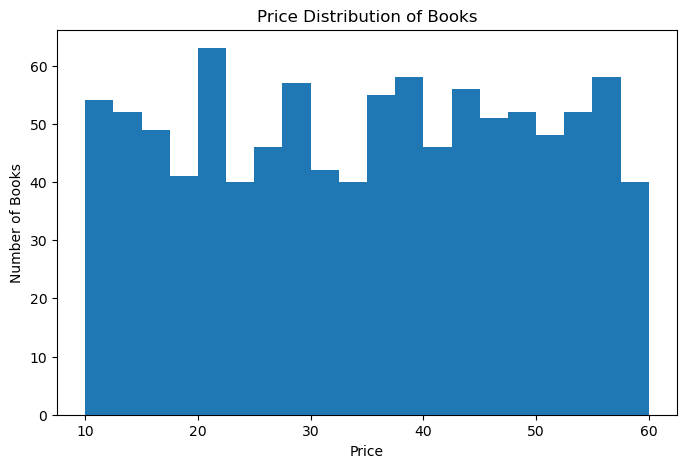

In [95]:
# First visualization - Showing the distribution of book prices
clean_df["Price"].plot(
    kind="hist",
    bins=20,
    figsize=(8, 5)
)

plt.xlabel("Price")
plt.ylabel("Number of Books")
plt.title("Price Distribution of Books")
plt.show()

In [96]:
#### 7.1.2 Rating Analysis

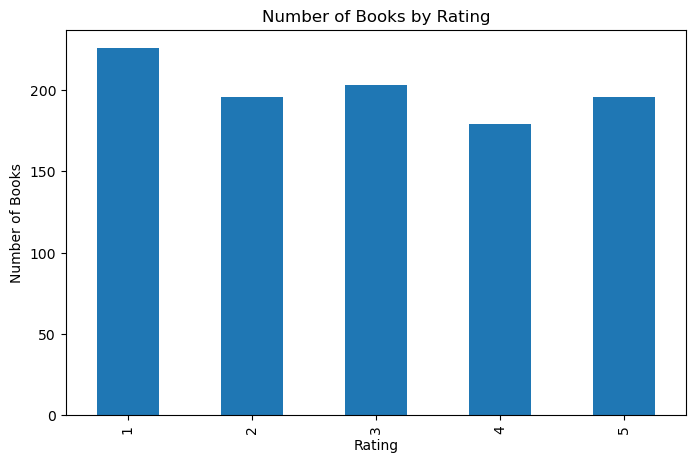

In [97]:
# Second visualization - Showing the number of books for each rating
clean_df["Rating"].value_counts().sort_index().plot(
    kind="bar",
    figsize=(8, 5)
)

plt.xlabel("Rating")
plt.ylabel("Number of Books")
plt.title("Number of Books by Rating")
plt.show()

In [98]:
#### 7.1.3 Availability Analysis

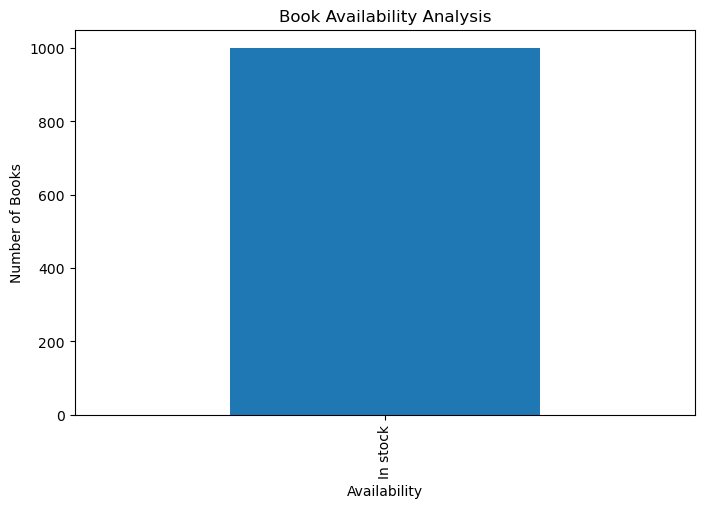

In [99]:
# Third visualization - Showing the availability of books
clean_df["Availability"].value_counts().plot(
    kind="bar",
    figsize=(8, 5)
)

plt.xlabel("Availability")
plt.ylabel("Number of Books")
plt.title("Book Availability Analysis")
plt.show()

In [100]:
### 7.2 Bivariate Analysis

In [101]:
#### 7.2.1 Category-wise Average Price

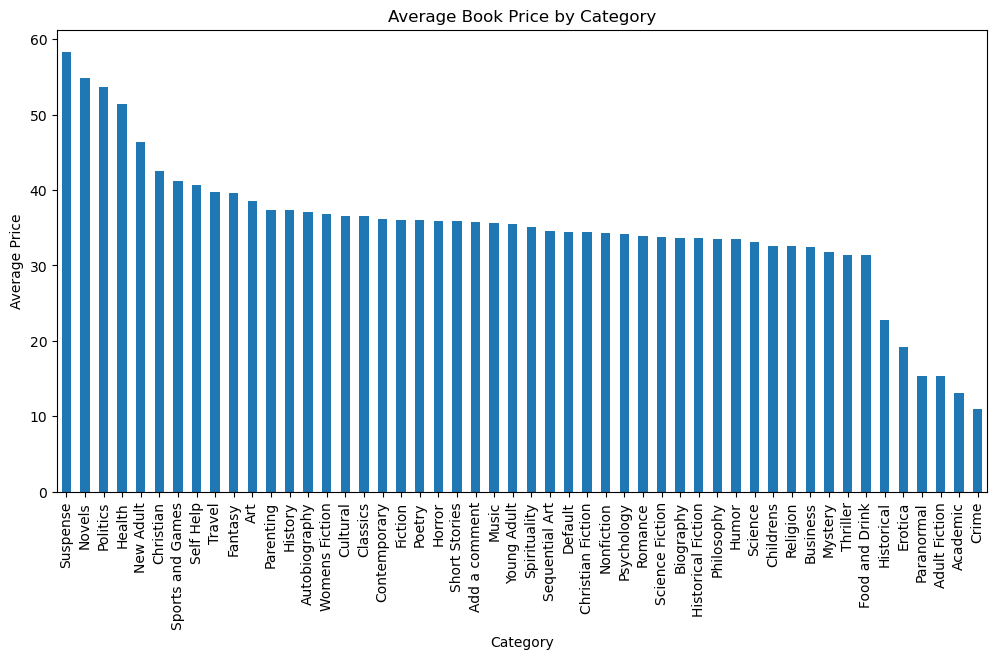

In [102]:
# Fourth visualization - Showing average price for each category
category_price = clean_df.groupby("Category")["Price"].mean().sort_values(ascending=False)

category_price.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.xlabel("Category")
plt.ylabel("Average Price")
plt.title("Average Book Price by Category")
plt.xticks(rotation=90)
plt.show()

In [103]:
#### 7.2.2 Number of Books by Price Category

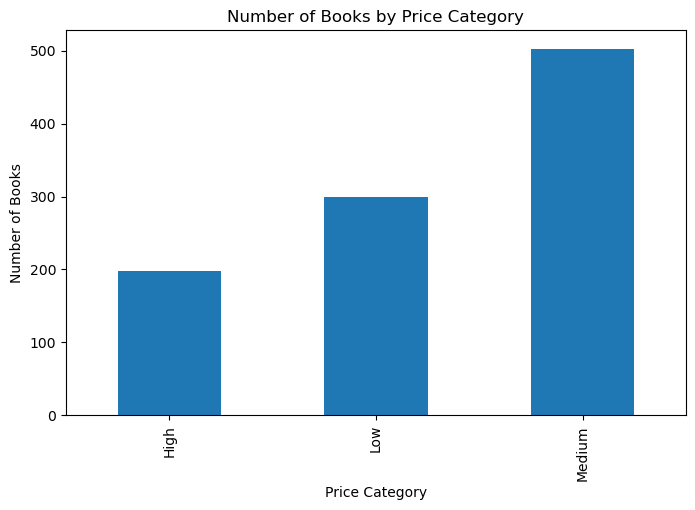

In [104]:
# Fifth visualization - Showing the number of books in each price category
clean_df["Price_Category"].value_counts().sort_index().plot(
    kind="bar",
    figsize=(8, 5)
)

plt.xlabel("Price Category")
plt.ylabel("Number of Books")
plt.title("Number of Books by Price Category")
plt.show()

In [105]:
#### 7.2.3 Rating vs Price

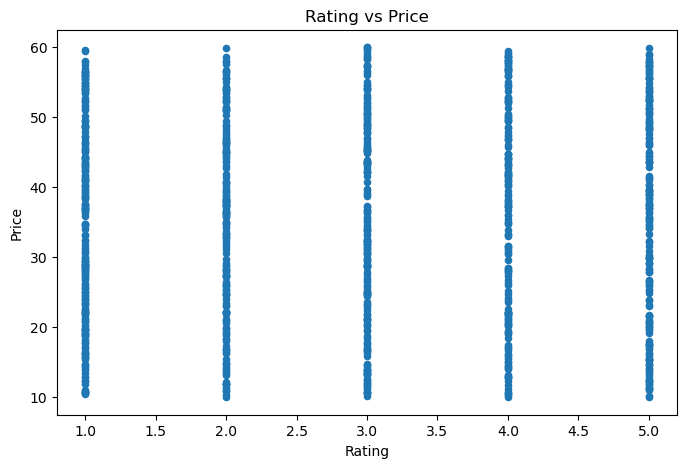

In [106]:
# Sixth visualization - Comparing rating and price
clean_df.plot(
    kind="scatter",
    x="Rating",
    y="Price",
    figsize=(8, 5)
)

plt.xlabel("Rating")
plt.ylabel("Price")
plt.title("Rating vs Price")
plt.show()

In [107]:
#### 7.2.4 Rating Category vs Price Category

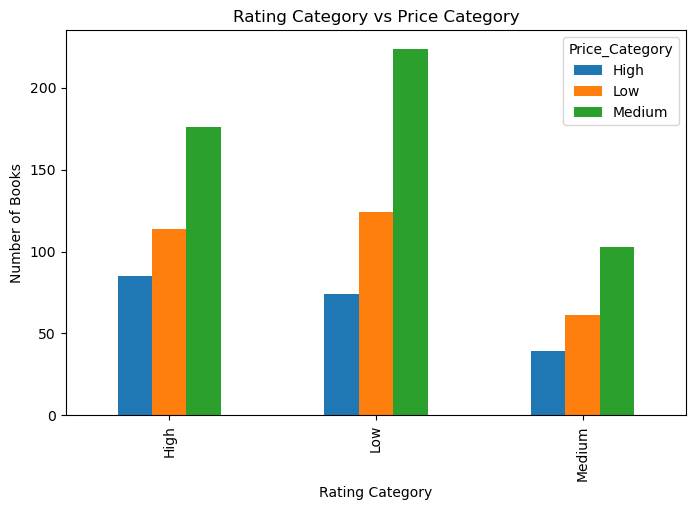

In [108]:
# Seventh visualization - Comparing rating category and price category
rating_price = pd.crosstab(
    clean_df["Rating_Category"],
    clean_df["Price_Category"]
)

rating_price.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.xlabel("Rating Category")
plt.ylabel("Number of Books")
plt.title("Rating Category vs Price Category")
plt.show()

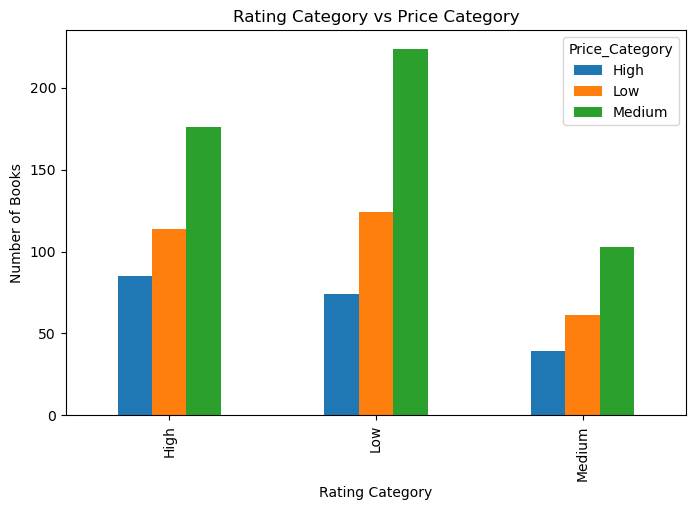

In [109]:
# Seventh visualization - Comparing rating category and price category
rating_price = pd.crosstab(
    clean_df["Rating_Category"],
    clean_df["Price_Category"]
)

rating_price.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.xlabel("Rating Category")
plt.ylabel("Number of Books")
plt.title("Rating Category vs Price Category")
plt.show()

In [110]:
### 7.3 Multivariate Analysis

In [111]:
#### 7.3.1 Category, Rating and Price Analysis

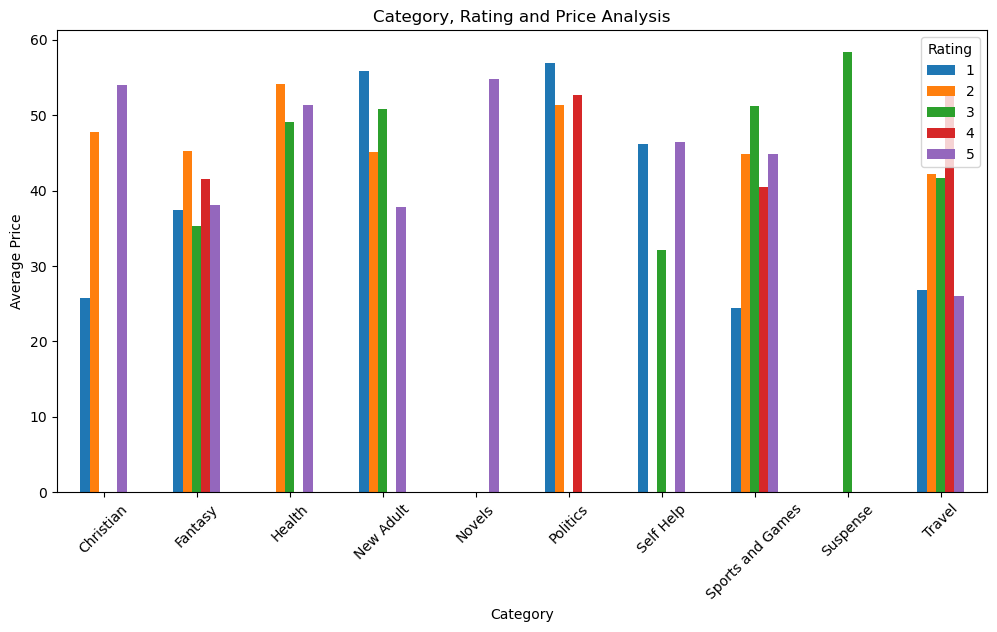

In [112]:
# Eighth visualization - Comparing category, rating and price
top_categories = (
    clean_df.groupby("Category")["Price"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
    .index
)

multivariate_data = clean_df[
    clean_df["Category"].isin(top_categories)
]

multivariate_data.groupby(
    ["Category", "Rating"]
)["Price"].mean().unstack().plot(
    kind="bar",
    figsize=(12, 6)
)

plt.xlabel("Category")
plt.ylabel("Average Price")
plt.title("Category, Rating and Price Analysis")
plt.xticks(rotation=45)
plt.show()

In [113]:
### 8. Business Questions and Answers ##

In [114]:
### Question 1: Which category has the highest average book price?

In [115]:
# Finding the category with the highest average price
category_average_price = clean_df.groupby("Category")["Price"].mean()
category_average_price.idxmax(), category_average_price.max()

('Suspense', 58.33)

Answer: The category with the highest average book price is Suspense, with an average price of 58.33.

In [116]:
### Question 2: Which category has the lowest average book price?

In [117]:
# Finding the category with the lowest average price
category_average_price = clean_df.groupby("Category")["Price"].mean()
category_average_price.idxmin(), category_average_price.min()

('Crime', 10.97)

Answer: The category with the lowest average book price is Crime, with an average price of 10.97.

In [118]:
### Question 3: Which rating has the highest number of books?

In [119]:
# Finding the rating with the highest number of books
rating_counts = clean_df["Rating"].value_counts()
rating_counts.idxmax(), rating_counts.max()

(np.int64(1), 226)

Answer: The 1-star rating has the highest number of books, with 226 books.

In [120]:
### Question 4: Which rating has the highest average book price?

In [121]:
# Finding the rating with the highest average price
rating_average_price = clean_df.groupby("Rating")["Price"].mean()
rating_average_price.idxmax(), rating_average_price.max()

(np.int64(4), 36.093296089385476)

Answer: Books with a 4-star rating have the highest average price, at 36.09.

In [122]:
### Question 5: How many books are currently in stock?

In [123]:
# Finding the number of books available in stock
availability_counts = clean_df["Availability"].value_counts()
availability_counts

Availability
In stock    1000
Name: count, dtype: int64

Answer: All 1000 books in the dataset are currently in stock.

In [124]:
### Question 6: What is the average price of all books?

In [125]:
# Finding the average price of all books
clean_df["Price"].mean()

np.float64(35.07035)

Answer: The average price of all books is 35.07.

In [126]:
### Question 7: What is the highest priced book?

In [127]:
# Finding the highest priced book
highest_price = clean_df["Price"].max()
clean_df[clean_df["Price"] == highest_price][["Book", "Price"]]

,Book,Price
191,The Perfect Play (Play by Play #1),59.99


Answer: The highest priced book is The Perfect Play (Play by Play #1), priced at 59.99.

In [128]:
### Question 8: What is the lowest priced book?

In [129]:
# Finding the lowest priced book
lowest_price = clean_df["Price"].min()
clean_df[clean_df["Price"] == lowest_price][["Book", "Price"]]

,Book,Price
781,An Abundance of Katherines,10.0


Answer: The lowest priced book is An Abundance of Katherines, priced at 10.00.

In [130]:
### Question 9: What percentage of books are currently available?

In [131]:
# Finding the percentage of books that are in stock
available_percentage = clean_df["Availability_Flag"].mean() * 100
available_percentage

np.float64(100.0)

Answer: 100% of the books in the dataset are currently available.

In [132]:
### Question 10: What is the average rating of all books?

In [133]:
# Finding the average rating of all books
clean_df["Rating"].mean()

np.float64(2.923)

Answer: The average rating of all books is 2.92.

In [134]:
### 9. Business Insights ###

Insight 1: Suspense books have the highest average price among all categories, at 58.33.

Insight 2: Crime books have the lowest average price among all categories, at 10.97.

Insight 3: Books with a 1-star rating are the most common rating group, with 226 books.

Insight 4: Books with a 4-star rating have the highest average price, at 36.09.

Insight 5: All 1000 books in the scraped dataset are currently listed as in stock.

Insight 6: The overall average price of books in the dataset is 35.07.

Insight 7: Book prices in the dataset range from 10.00 to 59.99.

Insight 8: The overall average rating of the books in the dataset is 2.92 out of 5.

In [135]:
### 10. Business Recommendations ###

Recommendation 1: The website can promote lower-priced books such as Crime books to attract price-sensitive customers.

Recommendation 2: Highlight highly rated books to help customers identify better-rated choices.

Recommendation 3: Use the 10.00 to 59.99 price range to provide customers with books across different price levels.

Recommendation 4: Give more visibility to 4-star rated books because they have the highest average price among the rating groups.

Recommendation 5: Maintain good stock availability because all the books in the scraped dataset are currently in stock.

In [136]:
### 10.1 Saving the Cleaned Dataset ###

In [138]:
# Saving the cleaned data as a CSV file
clean_df.to_csv("cleaned_books_data.csv", index=False)

In [141]:
# Reading the cleaned CSV to check the saved file
check_df = pd.read_csv("cleaned_books_data.csv")
check_df.head()

,Book,Category,Price,Rating,Availability,Price_Category,Rating_Category,Availability_Flag
0,It's Only the Himalayas,Travel,45.17,2,In stock,Medium,Low,1
1,Full Moon over Noah’s Ark: An Odyssey to Mount...,Travel,49.43,4,In stock,Medium,High,1
2,See America: A Celebration of Our National Par...,Travel,48.87,3,In stock,Medium,Medium,1
3,Vagabonding: An Uncommon Guide to the Art of L...,Travel,36.94,2,In stock,Medium,Low,1
4,Under the Tuscan Sun,Travel,37.33,3,In stock,Medium,Medium,1


In [142]:
# Checking the number of rows and columns
check_df.shape

(1000, 8)

In [143]:
# Checking the final cleaned dataset
check_df.dtypes

Book                  object
Category              object
Price                float64
Rating                 int64
Availability          object
Price_Category        object
Rating_Category       object
Availability_Flag      int64
dtype: object

### Conclusion ###
This project analyzed book data collected from Books to Scrape. The data was scraped from multiple pages and categories, cleaned using Pandas and Regular Expressions, and analyzed using different EDA techniques. The analysis helped understand book prices, ratings, categories, and availability. Based on the findings, business insights and recommendations were provided.